In [9]:
import pandas as pd
url = 'data.csv'
da = pd.read_csv(url)

In [11]:
da

,ID,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0,0,1,1,1,40,1,0,0,0,...,1,0,5,18,15,1,0,9,4,3
1,1,0,0,0,0,25,1,0,0,1,...,0,1,3,0,0,0,0,7,6,1
2,2,0,1,1,1,28,0,0,0,0,...,1,1,5,30,30,1,0,9,4,8
3,3,0,1,0,1,27,0,0,0,1,...,1,0,2,0,0,0,0,11,3,6
4,4,0,1,1,1,24,0,0,0,1,...,1,0,2,3,0,0,0,11,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,253675,0,1,1,1,45,0,0,0,0,...,1,0,3,0,5,0,1,5,6,7
253676,253676,1,1,1,1,18,0,0,0,0,...,1,0,4,0,0,1,0,11,2,4
253677,253677,0,0,0,1,28,0,0,0,1,...,1,0,1,0,0,0,0,2,5,2
253678,253678,0,1,0,1,23,0,0,0,0,...,1,0,3,0,0,0,1,7,5,1


In [14]:
da.columns

Index(['ID', 'Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI',
       'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits',
       'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost',
       'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age',
       'Education', 'Income'],
      dtype='str')

In [17]:
da['Smoker'].unique()

array([1, 0])

In [25]:
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

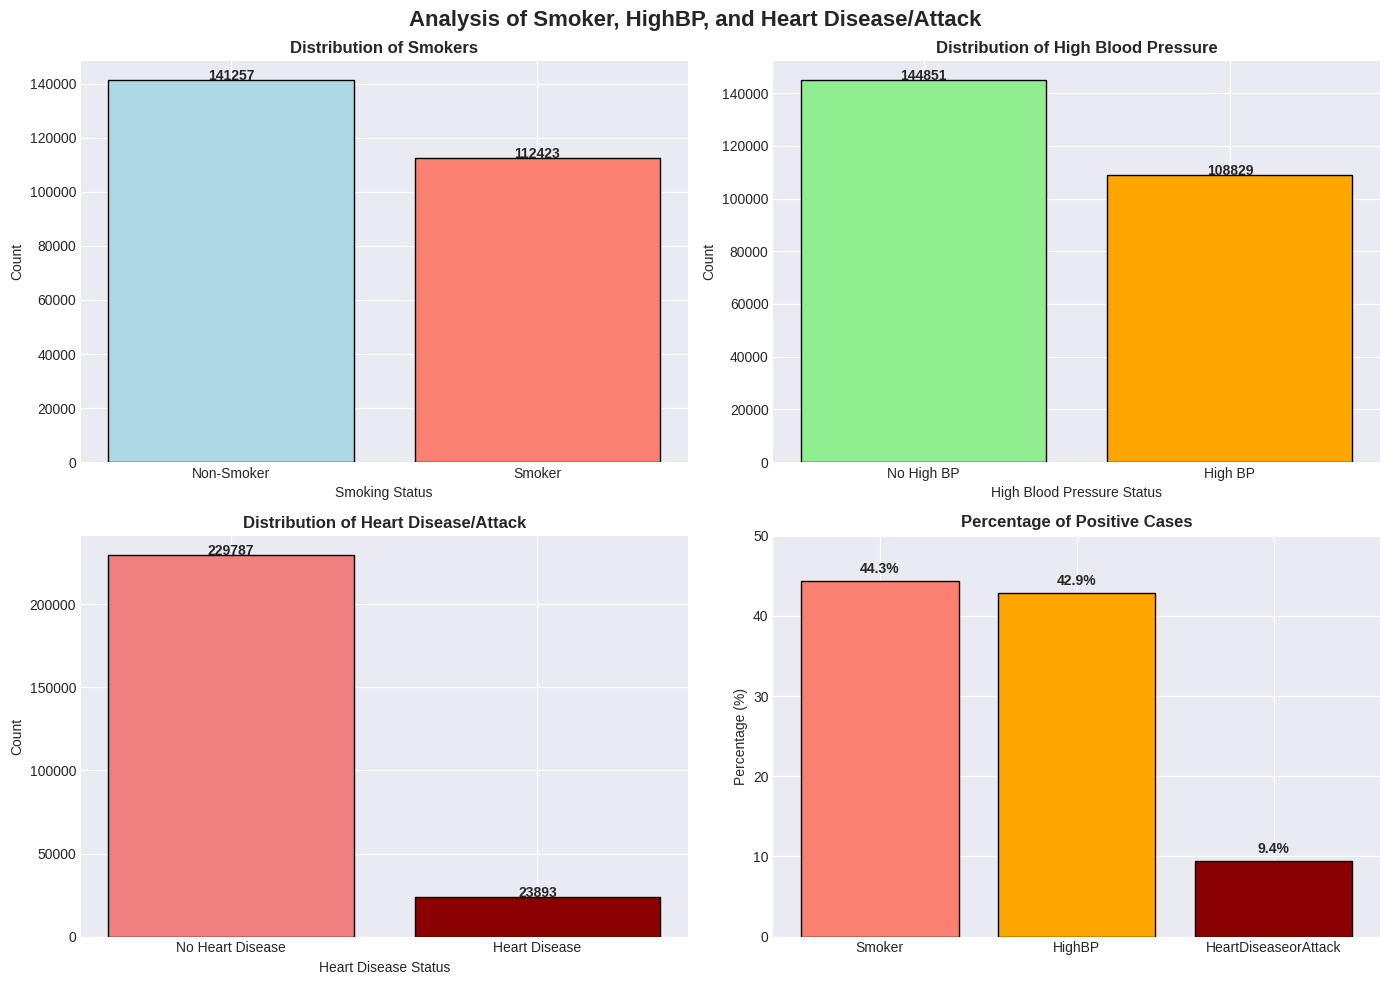

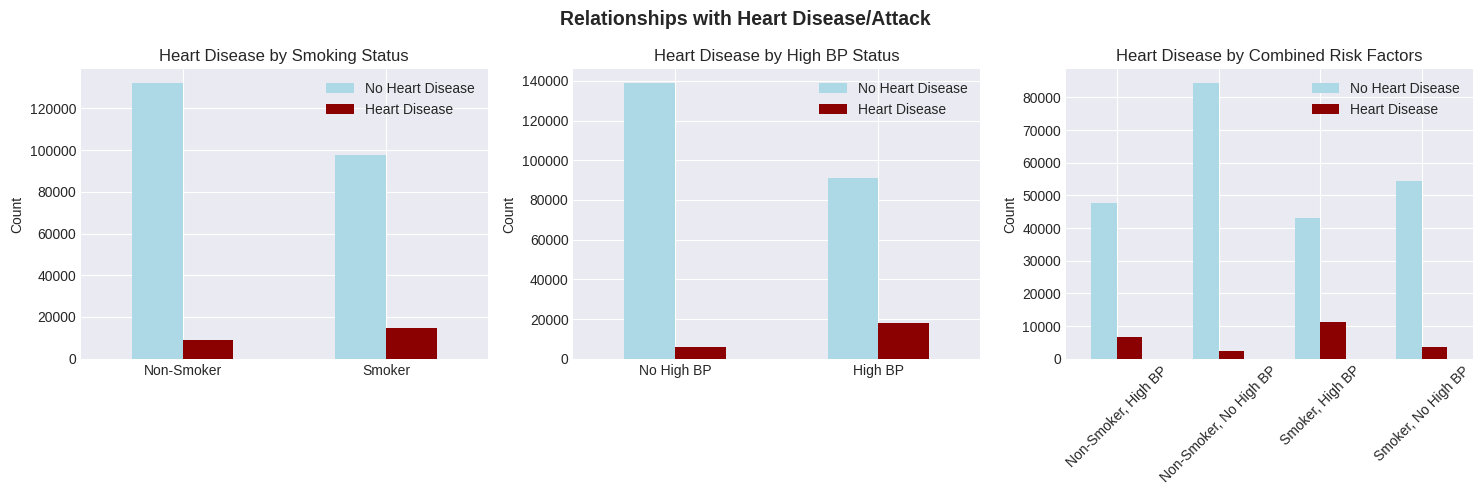

RISK ANALYSIS

Heart Disease Rate in Smokers: 13.17%
Heart Disease Rate in Non-Smokers: 6.44%
Risk Ratio (Smoker vs Non-Smoker): 2.05

Heart Disease Rate in High BP: 16.47%
Heart Disease Rate in Normal BP: 4.12%
Risk Ratio (High BP vs Normal BP): 4.00

Heart Disease Rate by Risk Factors:
  Non-Smoker, Normal BP: 2.67%
  Non-Smoker, High BP: 12.43%
  Smoker, Normal BP: 6.28%
  Smoker, High BP: 20.54%


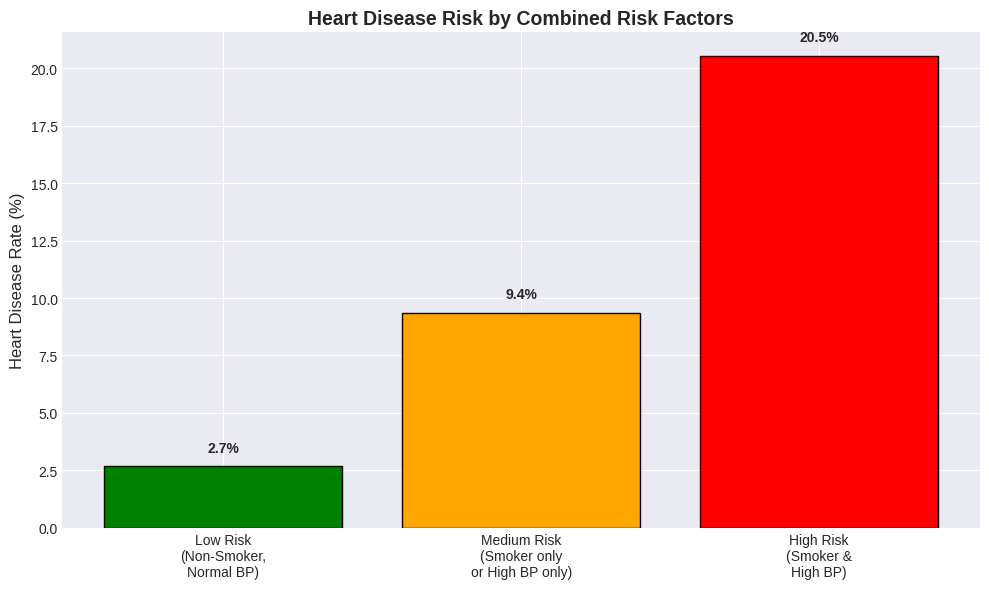


KEY FINDINGS:
• 13.2% of smokers have heart disease vs 6.4% of non-smokers
• 16.5% of people with high BP have heart disease vs 4.1% with normal BP
• People with BOTH smoking and high BP have 20.5% heart disease rate
• That's 7.7x higher than those with neither risk factor


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the data
df = pd.read_csv('data.csv')

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Analysis of Smoker, HighBP, and Heart Disease/Attack', fontsize=16, fontweight='bold')

# 1. Distribution of Smoker
smoker_counts = df['Smoker'].value_counts()
axes[0, 0].bar(['Non-Smoker', 'Smoker'], smoker_counts.values, 
                color=['lightblue', 'salmon'], edgecolor='black')
axes[0, 0].set_title('Distribution of Smokers', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_xlabel('Smoking Status')
for i, v in enumerate(smoker_counts.values):
    axes[0, 0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# 2. Distribution of HighBP
bp_counts = df['HighBP'].value_counts()
axes[0, 1].bar(['No High BP', 'High BP'], bp_counts.values,
                color=['lightgreen', 'orange'], edgecolor='black')
axes[0, 1].set_title('Distribution of High Blood Pressure', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_xlabel('High Blood Pressure Status')
for i, v in enumerate(bp_counts.values):
    axes[0, 1].text(i, v + 100, str(v), ha='center', fontweight='bold')

# 3. Distribution of Heart Disease/Attack
heart_counts = df['HeartDiseaseorAttack'].value_counts()
axes[1, 0].bar(['No Heart Disease', 'Heart Disease'], heart_counts.values,
                color=['lightcoral', 'darkred'], edgecolor='black')
axes[1, 0].set_title('Distribution of Heart Disease/Attack', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_xlabel('Heart Disease Status')
for i, v in enumerate(heart_counts.values):
    axes[1, 0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# 4. Percentage distribution
categories = ['Smoker', 'HighBP', 'HeartDiseaseorAttack']
percentages = []
for cat in categories:
    counts = df[cat].value_counts()
    percentages.append(counts[1] / len(df) * 100)

axes[1, 1].bar(categories, percentages, color=['salmon', 'orange', 'darkred'], edgecolor='black')
axes[1, 1].set_title('Percentage of Positive Cases', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Percentage (%)')
axes[1, 1].set_ylim(0, 50)
for i, v in enumerate(percentages):
    axes[1, 1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Create additional plot: Relationship between variables
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Relationships with Heart Disease/Attack', fontsize=14, fontweight='bold')

# 1. Heart Disease by Smoking Status
heart_by_smoker = pd.crosstab(df['Smoker'], df['HeartDiseaseorAttack'])
heart_by_smoker.columns = ['No Heart Disease', 'Heart Disease']
heart_by_smoker.index = ['Non-Smoker', 'Smoker']
heart_by_smoker.plot(kind='bar', ax=axes[0], color=['lightblue', 'darkred'])
axes[0].set_title('Heart Disease by Smoking Status', fontsize=12)
axes[0].set_ylabel('Count')
axes[0].set_xlabel('')
axes[0].legend(title='')
axes[0].tick_params(axis='x', rotation=0)

# 2. Heart Disease by HighBP Status
heart_by_bp = pd.crosstab(df['HighBP'], df['HeartDiseaseorAttack'])
heart_by_bp.columns = ['No Heart Disease', 'Heart Disease']
heart_by_bp.index = ['No High BP', 'High BP']
heart_by_bp.plot(kind='bar', ax=axes[1], color=['lightblue', 'darkred'])
axes[1].set_title('Heart Disease by High BP Status', fontsize=12)
axes[1].set_ylabel('Count')
axes[1].set_xlabel('')
axes[1].legend(title='')
axes[1].tick_params(axis='x', rotation=0)

# 3. Heart Disease by Smoker & HighBP Combined
df['Smoker_HighBP'] = df['Smoker'].astype(str) + '_' + df['HighBP'].astype(str)
smoker_bp_labels = {
    '0_0': 'Non-Smoker, No High BP',
    '0_1': 'Non-Smoker, High BP',
    '1_0': 'Smoker, No High BP',
    '1_1': 'Smoker, High BP'
}
df['Smoker_HighBP_Label'] = df['Smoker_HighBP'].map(smoker_bp_labels)
heart_by_combined = pd.crosstab(df['Smoker_HighBP_Label'], df['HeartDiseaseorAttack'])
heart_by_combined.columns = ['No Heart Disease', 'Heart Disease']
heart_by_combined.plot(kind='bar', ax=axes[2], color=['lightblue', 'darkred'])
axes[2].set_title('Heart Disease by Combined Risk Factors', fontsize=12)
axes[2].set_ylabel('Count')
axes[2].set_xlabel('')
axes[2].legend(title='')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Calculate risk ratios
print("="*60)
print("RISK ANALYSIS")
print("="*60)

# Heart Disease rate in smokers vs non-smokers
heart_smoker = df[df['Smoker'] == 1]['HeartDiseaseorAttack'].mean() * 100
heart_non_smoker = df[df['Smoker'] == 0]['HeartDiseaseorAttack'].mean() * 100
print(f"\nHeart Disease Rate in Smokers: {heart_smoker:.2f}%")
print(f"Heart Disease Rate in Non-Smokers: {heart_non_smoker:.2f}%")
print(f"Risk Ratio (Smoker vs Non-Smoker): {heart_smoker/heart_non_smoker:.2f}")

# Heart Disease rate in high BP vs normal BP
heart_highbp = df[df['HighBP'] == 1]['HeartDiseaseorAttack'].mean() * 100
heart_normalbp = df[df['HighBP'] == 0]['HeartDiseaseorAttack'].mean() * 100
print(f"\nHeart Disease Rate in High BP: {heart_highbp:.2f}%")
print(f"Heart Disease Rate in Normal BP: {heart_normalbp:.2f}%")
print(f"Risk Ratio (High BP vs Normal BP): {heart_highbp/heart_normalbp:.2f}")

# Combined risk
df_combined = df.groupby(['Smoker', 'HighBP'])['HeartDiseaseorAttack'].mean() * 100
print(f"\nHeart Disease Rate by Risk Factors:")
for (smoker, bp), rate in df_combined.items():
    smoker_text = "Smoker" if smoker else "Non-Smoker"
    bp_text = "High BP" if bp else "Normal BP"
    print(f"  {smoker_text}, {bp_text}: {rate:.2f}%")

# Create a stacked bar chart for risk levels
fig, ax = plt.subplots(figsize=(10, 6))
risk_levels = ['Low Risk\n(Non-Smoker,\nNormal BP)', 
               'Medium Risk\n(Smoker only\nor High BP only)', 
               'High Risk\n(Smoker &\nHigh BP)']

low_risk = df[(df['Smoker'] == 0) & (df['HighBP'] == 0)]['HeartDiseaseorAttack'].mean() * 100
medium_risk_smoker = df[(df['Smoker'] == 1) & (df['HighBP'] == 0)]['HeartDiseaseorAttack'].mean() * 100
medium_risk_bp = df[(df['Smoker'] == 0) & (df['HighBP'] == 1)]['HeartDiseaseorAttack'].mean() * 100
medium_risk = (medium_risk_smoker + medium_risk_bp) / 2
high_risk = df[(df['Smoker'] == 1) & (df['HighBP'] == 1)]['HeartDiseaseorAttack'].mean() * 100

risk_rates = [low_risk, medium_risk, high_risk]
colors = ['green', 'orange', 'red']

bars = ax.bar(risk_levels, risk_rates, color=colors, edgecolor='black')
ax.set_ylabel('Heart Disease Rate (%)', fontsize=12)
ax.set_title('Heart Disease Risk by Combined Risk Factors', fontsize=14, fontweight='bold')

for bar, rate in zip(bars, risk_rates):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{rate:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("KEY FINDINGS:")
print("="*60)
print(f"• {heart_smoker:.1f}% of smokers have heart disease vs {heart_non_smoker:.1f}% of non-smokers")
print(f"• {heart_highbp:.1f}% of people with high BP have heart disease vs {heart_normalbp:.1f}% with normal BP")
print(f"• People with BOTH smoking and high BP have {high_risk:.1f}% heart disease rate")
print(f"• That's {high_risk/low_risk:.1f}x higher than those with neither risk factor")

BERNOULLI DISTRIBUTION - Smoker


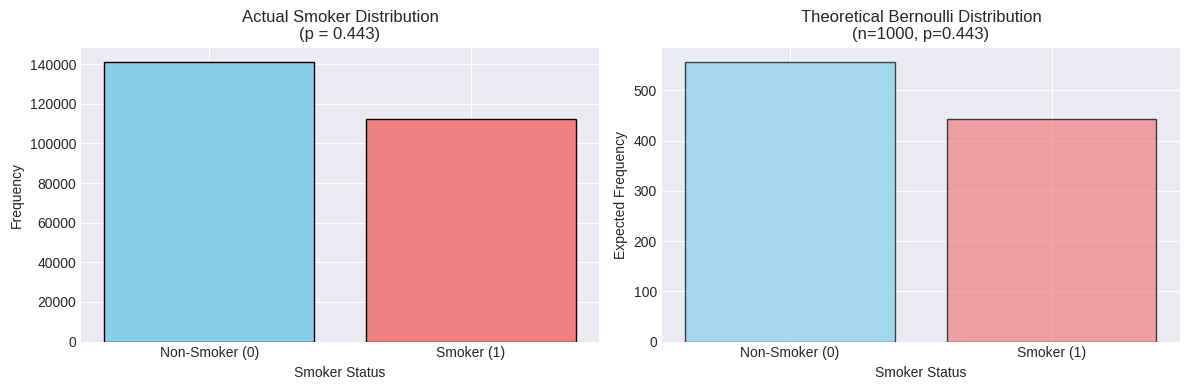

Bernoulli Parameter (p) = 0.4432
Probability of being a smoker: 44.32%
Probability of being a non-smoker: 55.68%

BINOMIAL DISTRIBUTION - High Blood Pressure


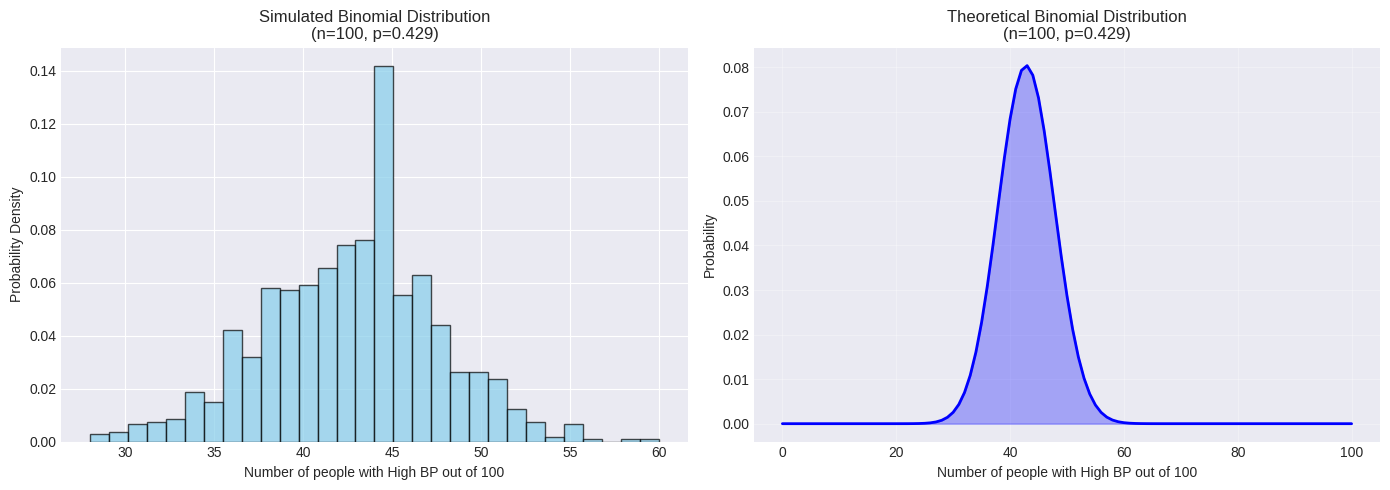

Binomial Parameters: n = 100, p = 0.4290
Expected number with High BP: 42.90
Variance: 24.50

NORMAL DISTRIBUTION - BMI


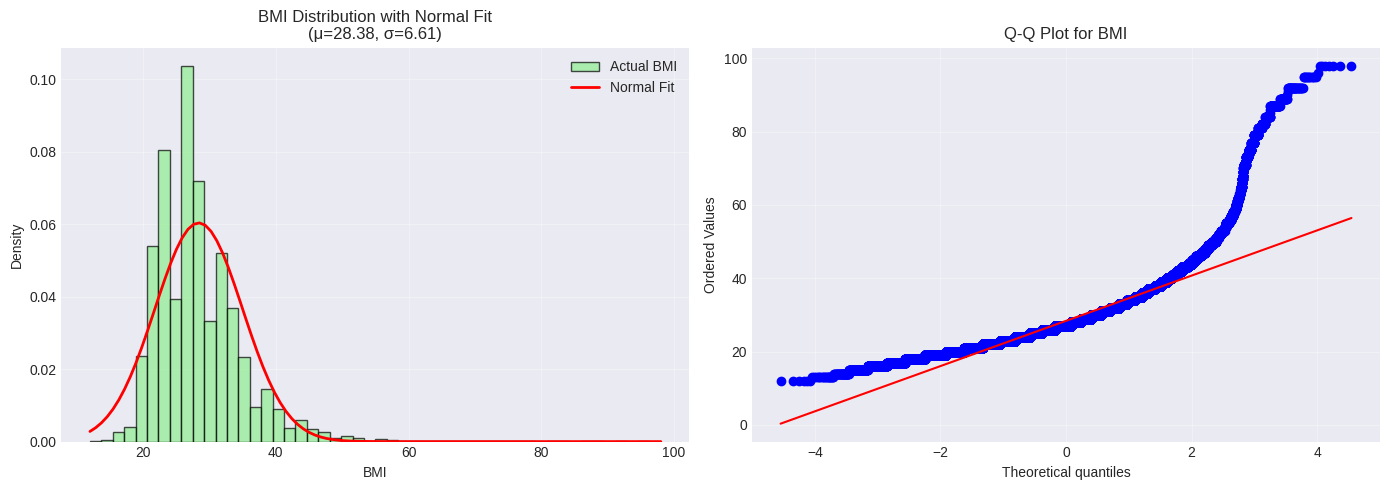

Normal Distribution Parameters:
  Mean (μ) = 28.3824
  Standard Deviation (σ) = 6.6087
  Skewness = 2.1220
  Kurtosis = 10.9975

POISSON DISTRIBUTION - Mental Health Days (MentHlth)


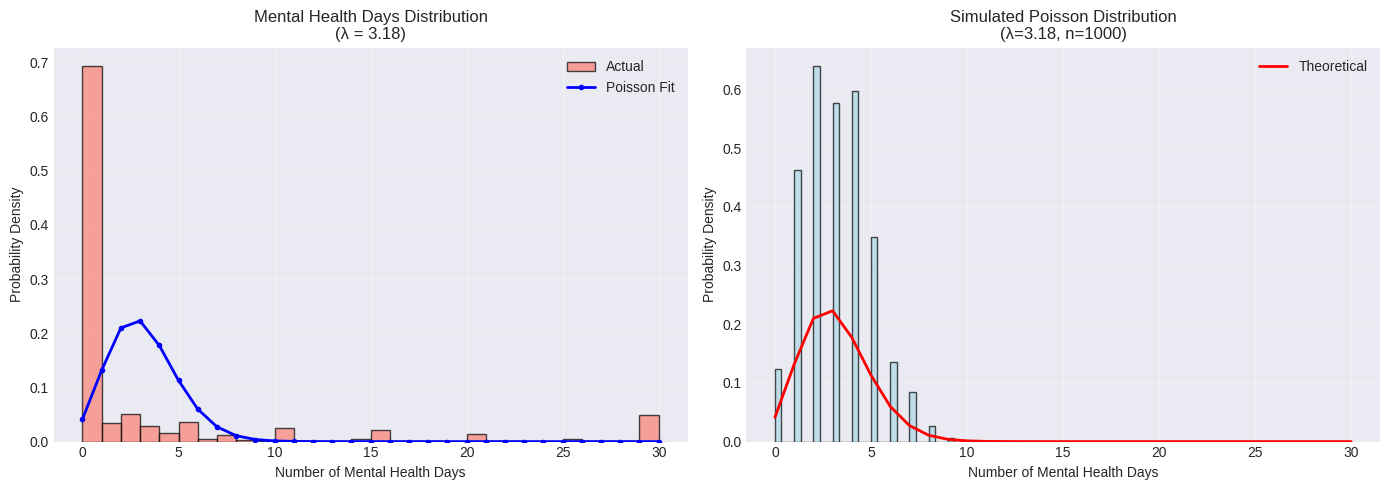

Poisson Parameter (λ) = 3.1848
Mean of actual data: 3.1848
Variance of actual data: 54.9503
(For Poisson, mean should ≈ variance: 51.7655)

UNIFORM DISTRIBUTION - Age


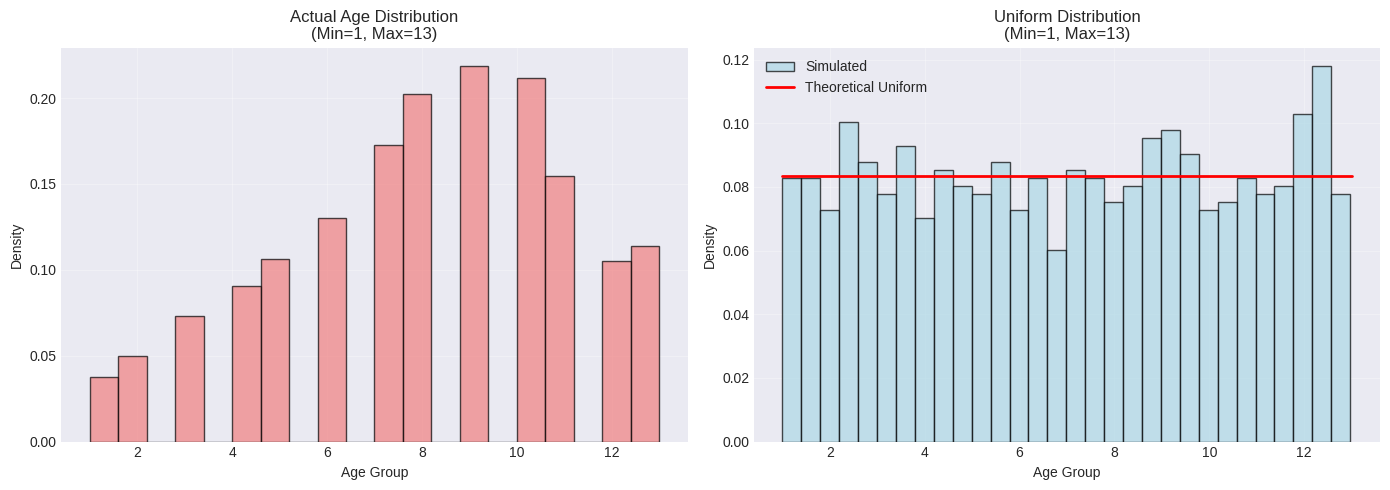

Uniform Distribution Parameters:
  Minimum (a) = 1
  Maximum (b) = 13
  Range = 12
  Expected mean = 7.00
  Actual mean = 8.03
  Expected variance = 12.00
  Actual variance = 9.33


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

# Load the data
df = pd.read_csv('data.csv')

# ============================================
# 1. BERNOULLI DISTRIBUTION
# Applied to: Smoker (binary variable)
# ============================================
print("="*60)
print("BERNOULLI DISTRIBUTION - Smoker")
print("="*60)

# Calculate probability of success (being a smoker)
p_smoker = df['Smoker'].mean()

# Generate Bernoulli random variables
bernoulli_samples = np.random.binomial(1, p_smoker, 1000)

# Plot actual vs theoretical Bernoulli distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Actual distribution
actual_counts = df['Smoker'].value_counts().sort_index()
axes[0].bar(['Non-Smoker (0)', 'Smoker (1)'], actual_counts.values, 
            color=['skyblue', 'lightcoral'], edgecolor='black')
axes[0].set_title(f'Actual Smoker Distribution\n(p = {p_smoker:.3f})')
axes[0].set_ylabel('Frequency')
axes[0].set_xlabel('Smoker Status')

# Theoretical Bernoulli distribution
theoretical_counts = [1000 * (1 - p_smoker), 1000 * p_smoker]
axes[1].bar(['Non-Smoker (0)', 'Smoker (1)'], theoretical_counts, 
            color=['skyblue', 'lightcoral'], edgecolor='black', alpha=0.7)
axes[1].set_title(f'Theoretical Bernoulli Distribution\n(n=1000, p={p_smoker:.3f})')
axes[1].set_ylabel('Expected Frequency')
axes[1].set_xlabel('Smoker Status')

plt.tight_layout()
plt.show()

print(f"Bernoulli Parameter (p) = {p_smoker:.4f}")
print(f"Probability of being a smoker: {p_smoker*100:.2f}%")
print(f"Probability of being a non-smoker: {(1-p_smoker)*100:.2f}%")

# ============================================
# 2. BINOMIAL DISTRIBUTION
# Applied to: HighBP (binary variable) - number of successes in n trials
# ============================================
print("\n" + "="*60)
print("BINOMIAL DISTRIBUTION - High Blood Pressure")
print("="*60)

# Calculate probability of having high BP
p_highbp = df['HighBP'].mean()
n_trials = 100  # Number of trials (people)

# Generate Binomial distribution
binom_samples = np.random.binomial(n_trials, p_highbp, 1000)

# Theoretical Binomial probabilities
k_values = np.arange(0, n_trials + 1)
binom_pmf = stats.binom.pmf(k_values, n_trials, p_highbp)

# Plot Binomial distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of simulated Binomial samples
axes[0].hist(binom_samples, bins=30, density=True, alpha=0.7, color='skyblue', edgecolor='black')
axes[0].set_title(f'Simulated Binomial Distribution\n(n={n_trials}, p={p_highbp:.3f})')
axes[0].set_xlabel(f'Number of people with High BP out of {n_trials}')
axes[0].set_ylabel('Probability Density')

# Theoretical PMF
axes[1].plot(k_values, binom_pmf, 'b-', linewidth=2, label='Theoretical PMF')
axes[1].fill_between(k_values, 0, binom_pmf, alpha=0.3, color='blue')
axes[1].set_title(f'Theoretical Binomial Distribution\n(n={n_trials}, p={p_highbp:.3f})')
axes[1].set_xlabel(f'Number of people with High BP out of {n_trials}')
axes[1].set_ylabel('Probability')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Binomial Parameters: n = {n_trials}, p = {p_highbp:.4f}")
print(f"Expected number with High BP: {n_trials * p_highbp:.2f}")
print(f"Variance: {n_trials * p_highbp * (1-p_highbp):.2f}")

# ============================================
# 3. NORMAL DISTRIBUTION
# Applied to: BMI (continuous variable)
# ============================================
print("\n" + "="*60)
print("NORMAL DISTRIBUTION - BMI")
print("="*60)

# Calculate mean and standard deviation of BMI
bmi_mean = df['BMI'].mean()
bmi_std = df['BMI'].std()

# Generate Normal distribution samples
normal_samples = np.random.normal(bmi_mean, bmi_std, 1000)

# Plot Normal distribution fit
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with fitted Normal curve
axes[0].hist(df['BMI'], bins=50, density=True, alpha=0.7, color='lightgreen', edgecolor='black', label='Actual BMI')
x = np.linspace(df['BMI'].min(), df['BMI'].max(), 100)
axes[0].plot(x, stats.norm.pdf(x, bmi_mean, bmi_std), 'r-', linewidth=2, label='Normal Fit')
axes[0].set_title(f'BMI Distribution with Normal Fit\n(μ={bmi_mean:.2f}, σ={bmi_std:.2f})')
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Q-Q plot for normality check
stats.probplot(df['BMI'], dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot for BMI')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Normal Distribution Parameters:")
print(f"  Mean (μ) = {bmi_mean:.4f}")
print(f"  Standard Deviation (σ) = {bmi_std:.4f}")
print(f"  Skewness = {df['BMI'].skew():.4f}")
print(f"  Kurtosis = {df['BMI'].kurtosis():.4f}")

# ============================================
# 4. POISSON DISTRIBUTION
# Applied to: MentHlth (mental health days, count data)
# ============================================
print("\n" + "="*60)
print("POISSON DISTRIBUTION - Mental Health Days (MentHlth)")
print("="*60)

# Calculate lambda (mean) for mental health days
lambda_menthlth = df['MentHlth'].mean()

# Generate Poisson distribution samples
poisson_samples = np.random.poisson(lambda_menthlth, 1000)

# Theoretical Poisson probabilities
k_menthlth = np.arange(0, df['MentHlth'].max() + 1)
poisson_pmf = stats.poisson.pmf(k_menthlth, lambda_menthlth)

# Plot Poisson distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Theoretical
axes[0].hist(df['MentHlth'], bins=30, density=True, alpha=0.7, color='salmon', edgecolor='black', label='Actual')
axes[0].plot(k_menthlth, poisson_pmf, 'b-', linewidth=2, marker='o', markersize=3, label='Poisson Fit')
axes[0].set_title(f'Mental Health Days Distribution\n(λ = {lambda_menthlth:.2f})')
axes[0].set_xlabel('Number of Mental Health Days')
axes[0].set_ylabel('Probability Density')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Simulated Poisson samples
axes[1].hist(poisson_samples, bins=30, density=True, alpha=0.7, color='lightblue', edgecolor='black')
axes[1].plot(k_menthlth, poisson_pmf, 'r-', linewidth=2, label='Theoretical')
axes[1].set_title(f'Simulated Poisson Distribution\n(λ={lambda_menthlth:.2f}, n=1000)')
axes[1].set_xlabel('Number of Mental Health Days')
axes[1].set_ylabel('Probability Density')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Poisson Parameter (λ) = {lambda_menthlth:.4f}")
print(f"Mean of actual data: {df['MentHlth'].mean():.4f}")
print(f"Variance of actual data: {df['MentHlth'].var():.4f}")
print(f"(For Poisson, mean should ≈ variance: {abs(df['MentHlth'].mean() - df['MentHlth'].var()):.4f})")

# ============================================
# 5. UNIFORM DISTRIBUTION
# Applied to: Age (assuming uniform distribution across age groups)
# ============================================
print("\n" + "="*60)
print("UNIFORM DISTRIBUTION - Age")
print("="*60)

# Get min and max age
age_min = df['Age'].min()
age_max = df['Age'].max()

# Generate Uniform distribution samples
uniform_samples = np.random.uniform(age_min, age_max, 1000)

# Plot Uniform distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual Age distribution
axes[0].hist(df['Age'], bins=20, density=True, alpha=0.7, color='lightcoral', edgecolor='black', label='Actual')
axes[0].set_title(f'Actual Age Distribution\n(Min={age_min}, Max={age_max})')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Density')
axes[0].grid(True, alpha=0.3)

# Theoretical Uniform distribution
x_uniform = np.linspace(age_min, age_max, 100)
uniform_pdf = np.ones_like(x_uniform) / (age_max - age_min)
axes[1].hist(uniform_samples, bins=30, density=True, alpha=0.7, color='lightblue', edgecolor='black', label='Simulated')
axes[1].plot(x_uniform, uniform_pdf, 'r-', linewidth=2, label='Theoretical Uniform')
axes[1].set_title(f'Uniform Distribution\n(Min={age_min}, Max={age_max})')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Uniform Distribution Parameters:")
print(f"  Minimum (a) = {age_min}")
print(f"  Maximum (b) = {age_max}")
print(f"  Range = {age_max - age_min}")
print(f"  Expected mean = {(age_min + age_max)/2:.2f}")
print(f"  Actual mean = {df['Age'].mean():.2f}")
print(f"  Expected variance = {((age_max - age_min)**2)/12:.2f}")
print(f"  Actual variance = {df['Age'].var():.2f}")